In [1]:
from qiskit import QuantumCircuit

C:\Users\EricChatterjee2\AppData\Local\Temp\ipykernel_76580\3957343935.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


In [2]:
from qiskit.quantum_info import Operator

In [3]:
from qiskit.quantum_info import Statevector

In [4]:
import numpy as np

In [5]:
import matplotlib as mpl

In [6]:
# We are given a set of states |x'> \in {|0>,|1>,...|2^n - 1>}, where each state is an eigenstate of the operator U, with the
# eigenvalue being a unique phase e^{i*2*\pi*\theta(x')} = e^{i*2*\pi*t(x')}, where t(x') \in [0,1) and 2^d*\theta(x') is an
# integer (for a particular positive integer d) for any x'. The goal is to find the state |x'> = |x>, given t(x).

# We use n = 4 (corresponding to 16 possible basis states |x'>).

n = 4

In [7]:
# The core mechanism is to ultimately entangle each x' with the corresponding t(x'). To that end, we need to add the number of 
# ancillary bits necessary for representing all possible values of t. Since 2^d*\theta(x') is an integer for all values of x', 
# and since \theta(x') and t(x') differ by an integer, we deduce that 2^d*t(x') is an integer for every x'. Furthermore, the
# fact that t \in [0,1) implies that 2^d*t \in [0,2^d), meaning that we can represent every value of t(x') with d bits.

# To determine the lower bound for d, we consider the fact that there are 2^n unique values of t and 2^d available "slots" for
# those values. Consequently, 2^d >= 2^n, implying that d >= n. We choose d = 6.

d = 6

In [8]:
# We thus randomly choose t(x') values for all x' from 0 to 15, with the condition being that t(x') is an integer multiple of
# 1/2^d with the integer being in the range 0 through 2^d-1 (i.e., from 0 through 63 given d = 6).

tarray = 1/2**d*np.array([10, 5, 7, 47, 62, 2, 55, 34, 20, 38, 61, 25, 17, 44, 36, 52])

# We convert this array to a phase array and then to the diagonal gate U (where the basis states are (|0>,...,|2^n - 1>)).

phasearray = np.exp(1j*2*np.pi*tarray)
from qiskit.circuit.library import DiagonalGate
ugate = DiagonalGate(phasearray)
ugate.name = "U"
ugateinv = ugate.inverse()
ugateinv.name = "Uinv"

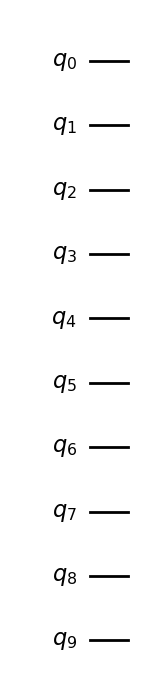

In [9]:
# We now consider the quantum circuit itself. We initialize n+d bits (where we aim to use the first n bits and the next d bits
# to represent x' and 2^d*t(x'), respectively).

qc = QuantumCircuit(n+d)

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [10]:
state.draw('latex')

<IPython.core.display.Latex object>

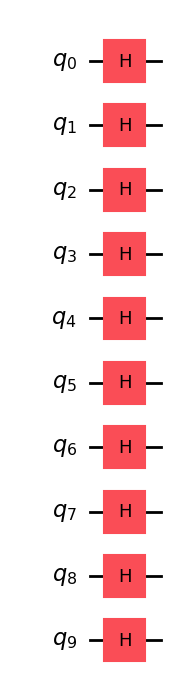

In [11]:
# We apply the Hadamard gate on all bits, yielding the superposition 1/\sqrt{2^(n+d)}*\sum_{t',x'} |2^d*t'> |x'>, where the t'
# values represent all possible "phase slots" (i.e., all values in the range 1/2^d*(0,1,2,...,2^d-1)).

qc.h(range(n+d))

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [12]:
state.draw('latex')

<IPython.core.display.Latex object>

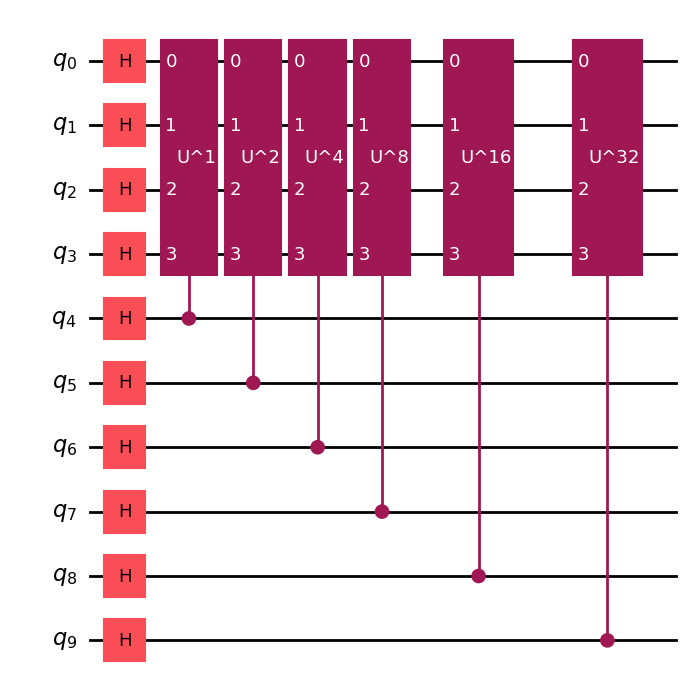

In [13]:
# Therefore, for each |x'>, this state features a superposition of all numerically possible phases. However, the goal is to
# create an entangled state where each |x'> is only associated with the corresponding phase |t(x')>. To achieve this, we apply
# the quantum phase estimation method. Specifically, we want to map |2^d*t'>|x'> \rightarrow
# e^{i*2*\pi*t(x')*(2^d*t')}|2^d*t'>|x'>, which is achieved by applying the operator U^{2^d*t'} =
# \prod_{l=0}^{d-1} C_{n+l} U^(2^l), where we apply the operator on the first n bits while using the next d bits individually as
# control qubits.

for dindex in range(d):
    ugateraised = ugate**(2**dindex)
    cugateraised = ugateraised.control(1)
    qc.append(cugateraised,[n+dindex] + list(range(n)))
    
state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [14]:
state.draw('latex')

<IPython.core.display.Latex object>

C:\Users\EricChatterjee2\AppData\Local\Temp\ipykernel_76580\2512936321.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=d, inverse=True)


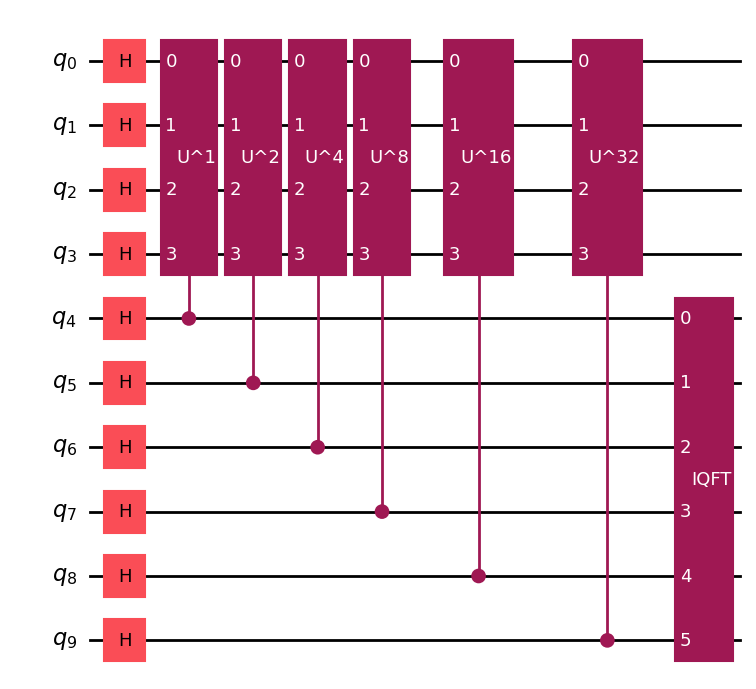

In [15]:
# The key here is that for each |x'>, there is no longer a symmetric superposition of all |2^d*t'> but rather a phase-weighted
# superposition, corresponding to the composite state \sum_{t',x'} e^{i*(2*\pi/2^d)*(2^d*t(x'))*(2^d*t')} |2^d*t'> |x'>. 
# Conceptually, the fact that consecutive integer states |2^d*t'> \in (|0>,...,|2^d - 1>) are separated by a well-defined phase
# (invariant in the particular integer pair), with the amplitudes for integer states being uniform, clearly demonstrates
# that this composite state is the QFT of \sum_{x'} |2^d*t(x')> |x'>, where every x' is entangled with the corresponding phase
# t(x'), as desired. We thus apply the inverse QFT on the d-bit system to achieve this entangled state.

from qiskit.circuit.library import QFT
iqft = QFT(num_qubits=d, inverse=True)
qc.append(iqft,range(n,n+d))

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [16]:
state.draw('latex')

<IPython.core.display.Latex object>

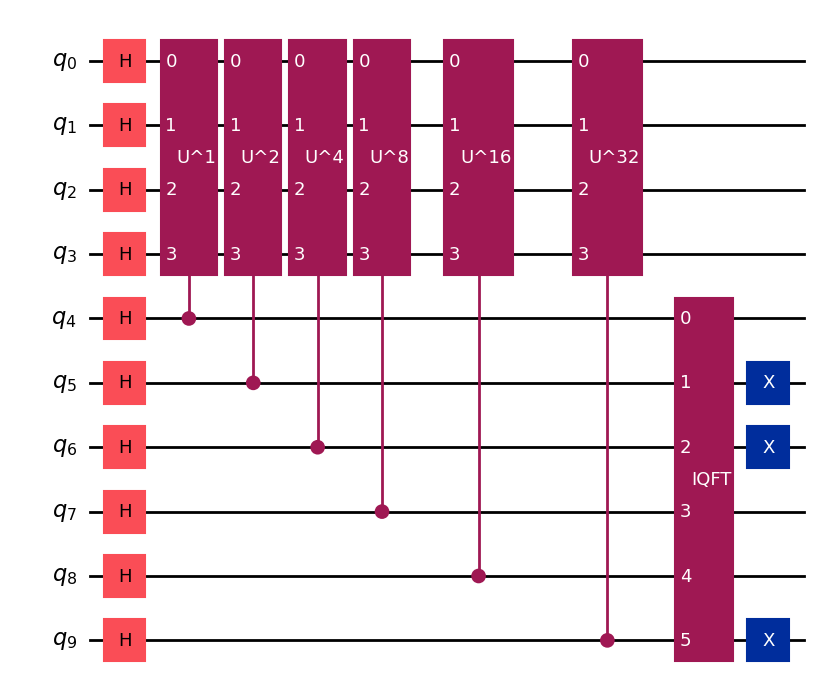

In [17]:
# Note the coefficient amplitude has changed from 1/\sqrt{2^(n+d)} to 1/\sqrt{2^n}, corresponding to the collapse of the |t'>
# superposition associated with each |x'> to the well-defined state |t(x')>.

# Now, we seek to use Grover's algorithm to distill this superposition down to the desired value of x' (i.e., x' = x).
# Conveniently, the x is fully marked by the corresponding given phase t(x) in the current composite state. The key is thus to
# define an oracle operator that targets the d-bit state |2^d*t(x)>. This can be accomplished by using a series of X gates to
# turn all d bits in that state into a string of 1s and then applying a multi-controlled Z gate using d-1 bits as controls and
# the leftover bit as the target. This will flip the phase of |2^d*t(x)>, while leaving all other d-bit states |2^d*t(x')>
# untouched. 

# The X-gate series can be practically implemented for a given value of 2^d*t(x), which we label as "numhold" as follows. We
# start by subtracting 2^{d-1} from numhold. If the result is non-negative, that means the (d-1)^st bit (where we are
# zero-indexing) corresponding to the 2^d*t(x) value is already 1, and we continue on to the next bit with the new value of
# numhold. On the other hand, if the result is negative, that means that the (d-1)^st bit is 0. In this case, we apply the X 
# gate to flip it to 1, along with reverting the numhold value to the original. We apply the same protocol to the (d-2)^nd bit, 
# (d-3)^rd bit, all the way to the 0^th bit.

# For our example, we will pick 2^d*t(x) = 25, corresponding to x = 11 (see "tarray" above)

tvalueexpanded = 25 # represents 2^d*t(x)

numhold = tvalueexpanded

for dindexreversed in range(d):
    dindex = d - dindexreversed - 1
    twoexpdindex = 2**dindex
    numhold = numhold - twoexpdindex
    if numhold < 0:
        qc.x(n+dindex)
        numhold = numhold + twoexpdindex
        
state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [18]:
state.draw('latex')

<IPython.core.display.Latex object>

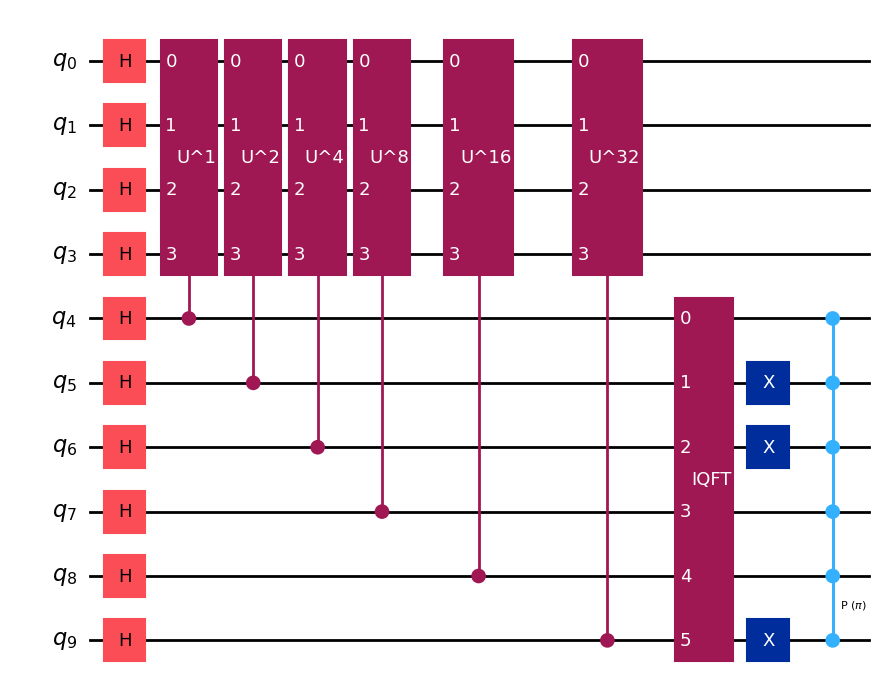

In [19]:
# As the diagram shows, the X gates were applied to the 1st, 2nd, and 5th bits of the d-bit string (where we define the string
# indices as ranging from 0 through 5). This comports with the positions of the 0s in the binary string for |25> (|011001>),
# which we have now converted to |111111>. Consequently, we can see from the last state in the new superposition that the d-bit
# state consisting of all 1s is now entangled with the x = 11 (i.e., |1011>). 

# We now construct the oracle operator using the multi-controlled Z gate on the latter d bits, as mentioned above. To do so, we
# use the general MCPhase gate with the phase set to \pi.

from qiskit.circuit.library import PhaseGate
zgate = PhaseGate(np.pi)
czgate = zgate.control(d-1)
qc.append(czgate,range(n,n+d))

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [20]:
state.draw('latex')

<IPython.core.display.Latex object>

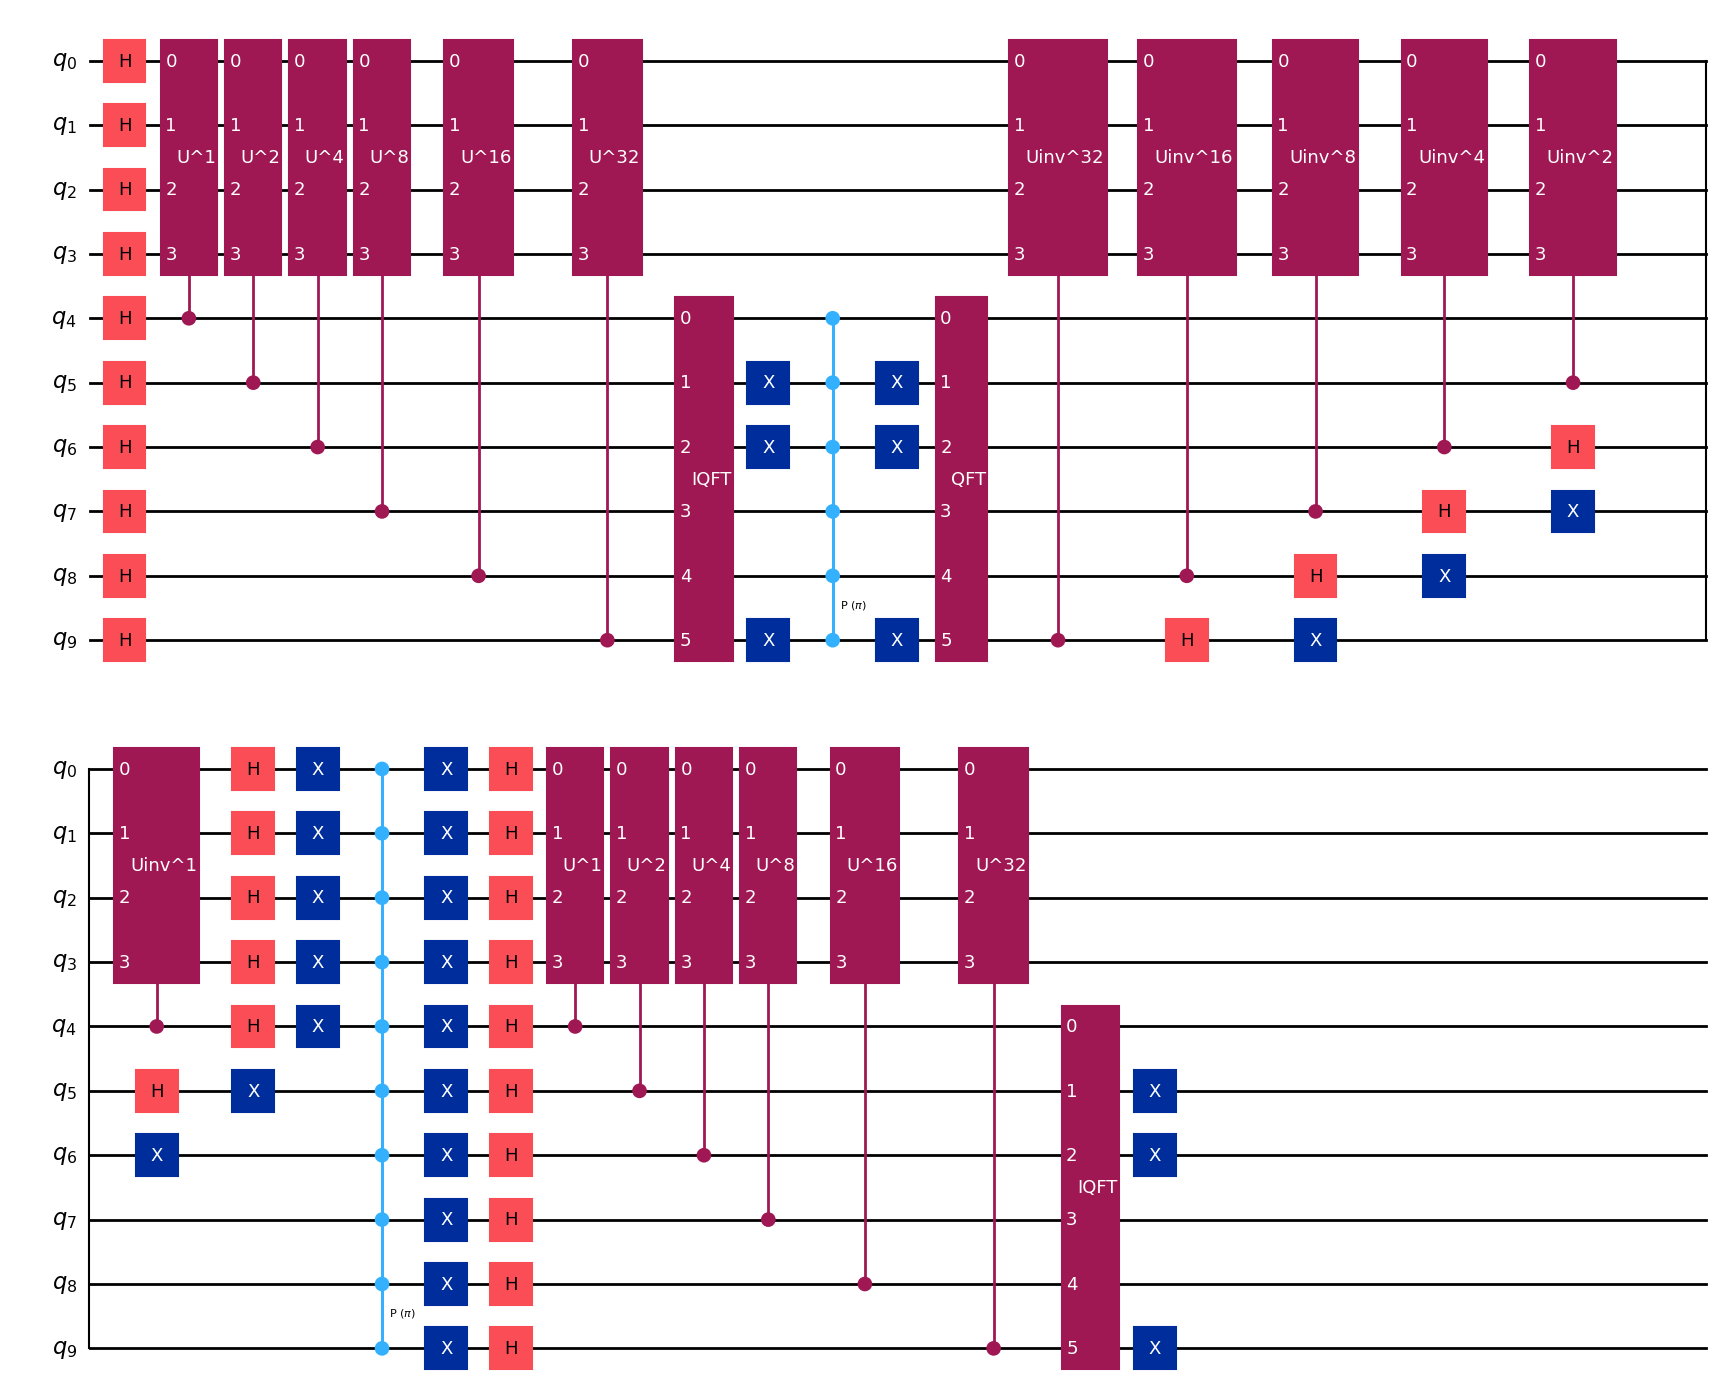

In [21]:
# As desired, the phase associated with the last state in this superposition (i.e., x = 11) has flipped, while all other phases
# are unchanged. 

# We now construct the diffusion operator. To do so, we apply the composite operator 
# A*(2|0...0><0...0| - I)*A^{\dag}, where A is the entire set of operations that we used to go from the
# (n+d)-bit vacuum state |0...0> to the entangled superposition upon which we applied the oracle operator.

# The operator 2|0...0><0...0| - I is in turn equivalent (up to a global sign flip) to applying the X gate on all bits, then
# applying an MCZ gate using n+d-1 bits as controls and the remaining bit as target (thus flipping the phase corresponding to
# the state |1...1>), and finally reverting the basis states back by applying the X gate on all bits again. The overall effect
# is to flip the phase of the |0...0> basis state in a given superposition while leaving the coefficients for all other basis
# states unchanged. For this, we define the necessary MCZ gate as follows:

czgate2 = zgate.control(n+d-1)

# We thus break the diffusion operator into individual steps, starting with A^{\dag}:

numhold = tvalueexpanded
for dindexreversed in range(d):
    dindex = d - dindexreversed - 1
    twoexpdindex = 2**dindex
    numhold = numhold - twoexpdindex
    if numhold < 0:
        qc.x(n+dindex)
        numhold = numhold + twoexpdindex
qc.append(iqft.inverse(),range(n,n+d))
for dindexreversed in range(d):
    dindex = d - dindexreversed - 1
    ugateinvraised = ugateinv**(2**dindex)
    cugateinvraised = ugateinvraised.control(1)
    qc.append(cugateinvraised,[n+dindex] + list(range(n)))
qc.h(range(n+d))

# Next, I - 2|0...0><0...0|:
    
qc.x(range(n+d))
qc.append(czgate2,range(n+d))
qc.x(range(n+d))

# And finally, A:
    
qc.h(range(n+d))
for dindex in range(d):
    ugateraised = ugate**(2**dindex)
    cugateraised = ugateraised.control(1)
    qc.append(cugateraised,[n+dindex] + list(range(n)))
qc.append(iqft,range(n,n+d))
numhold = tvalueexpanded
for dindexreversed in range(d):
    dindex = d - dindexreversed - 1
    twoexpdindex = 2**dindex
    numhold = numhold - twoexpdindex
    if numhold < 0:
        qc.x(n+dindex)
        numhold = numhold + twoexpdindex

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [22]:
state.draw('latex')

<IPython.core.display.Latex object>

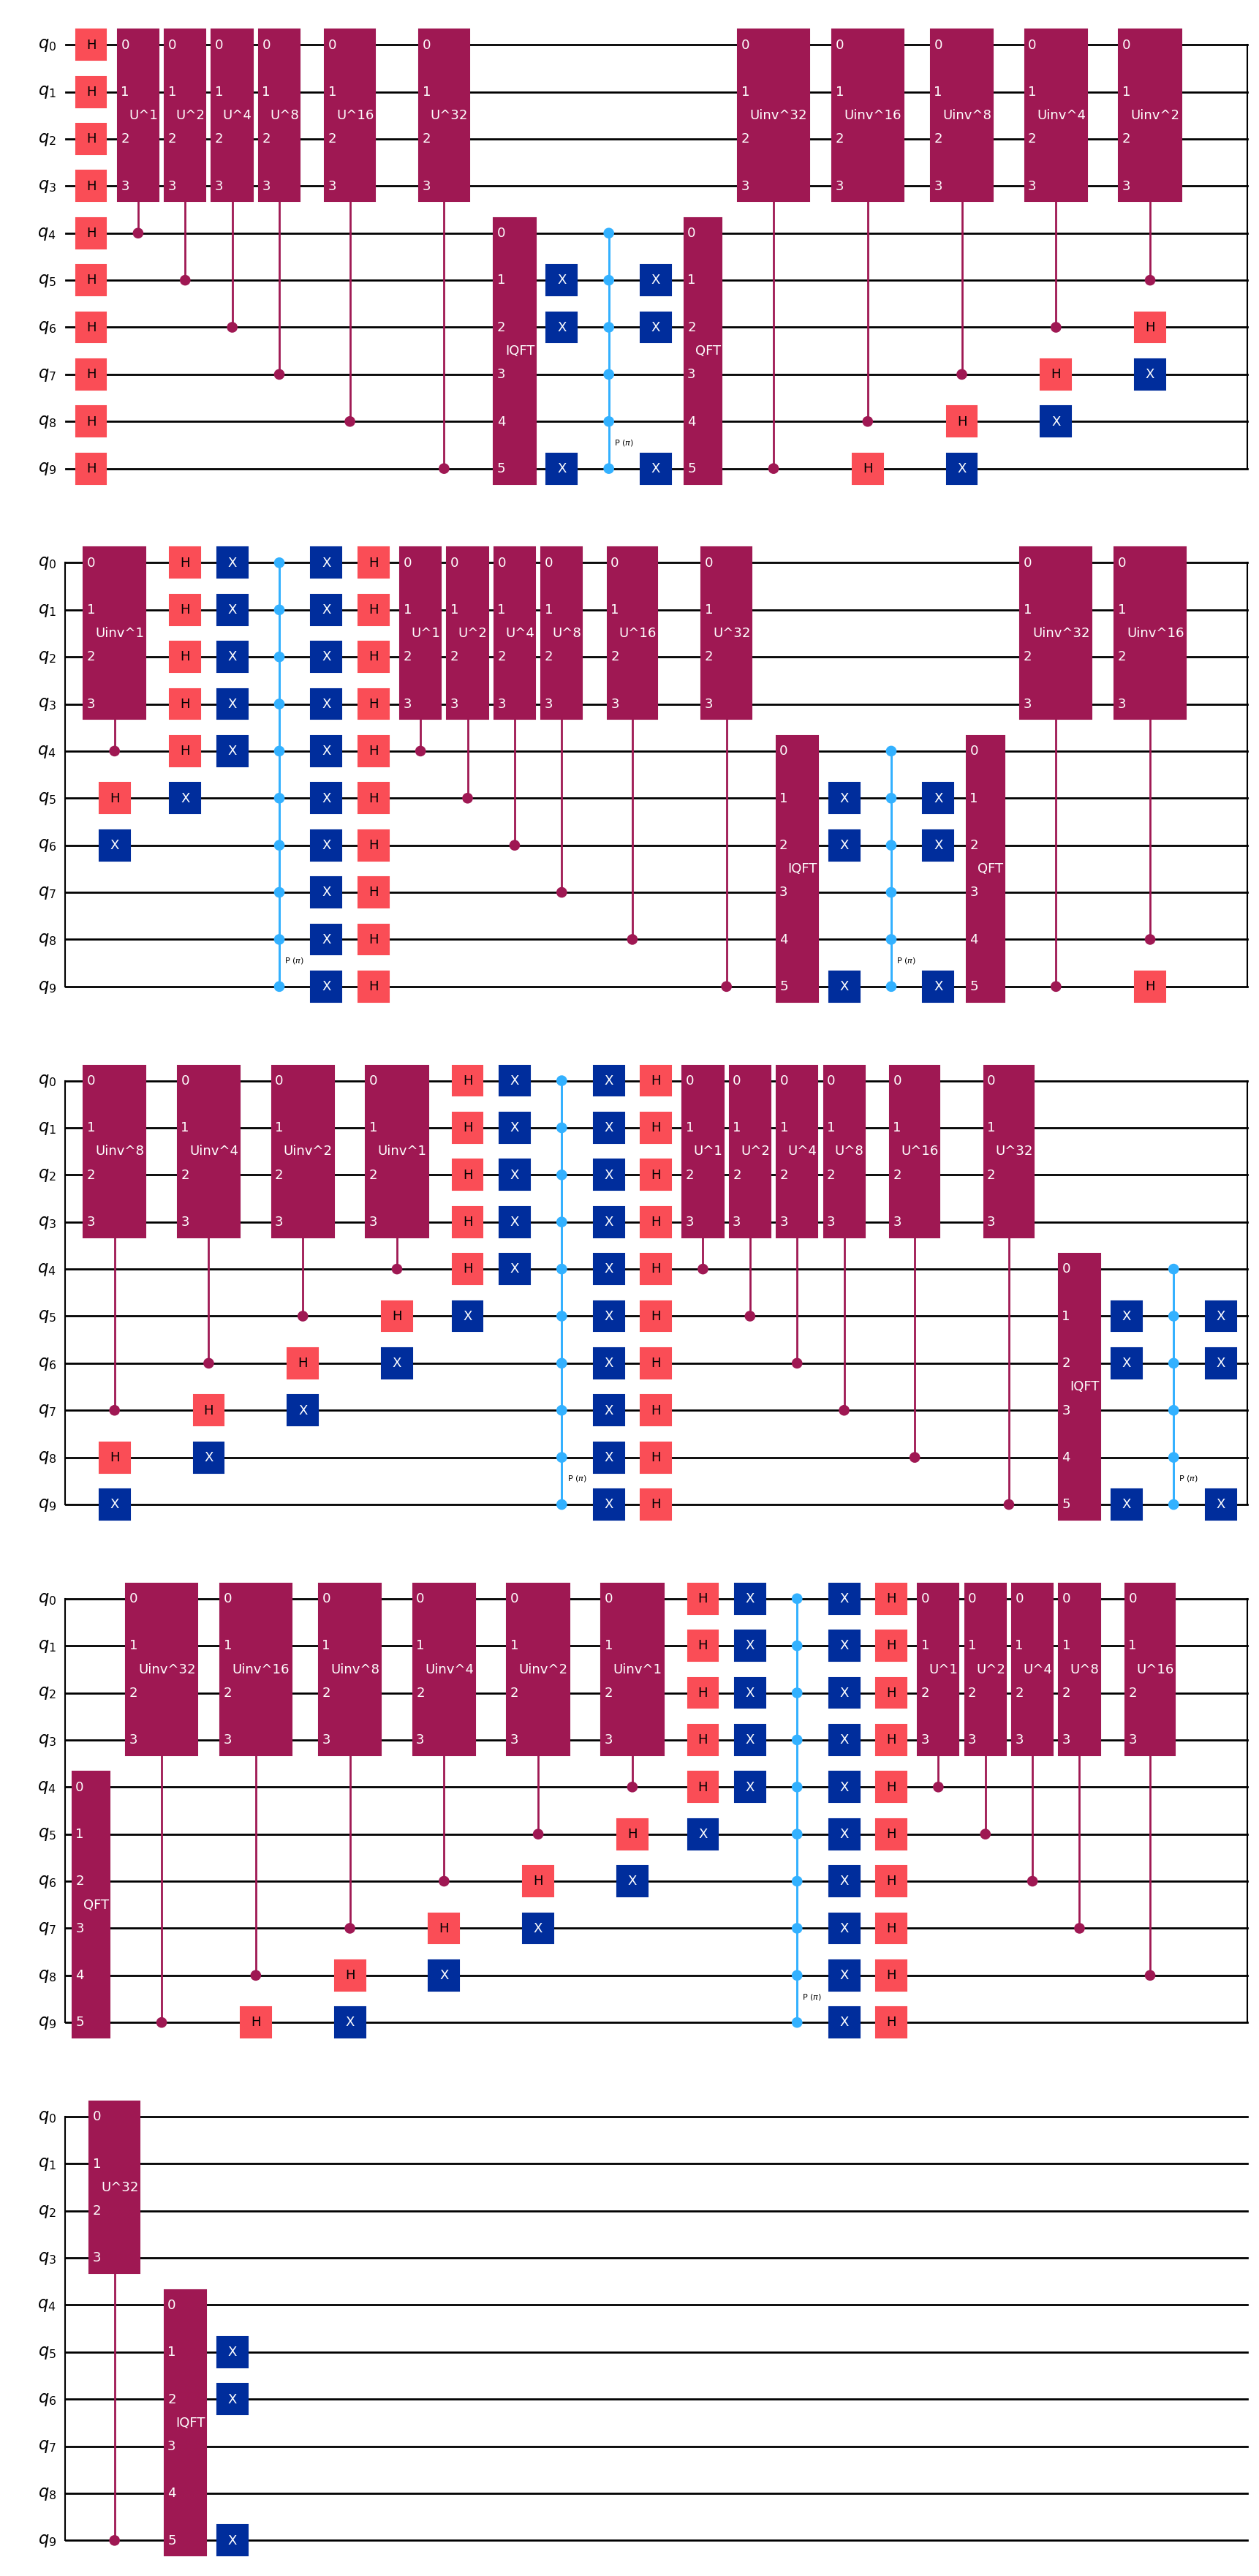

In [23]:
# In the above diagram, Uinv represents the inverse of U. As the state coefficients show, the state corresponding to x = 11 has
# been dramatically amplified. We run the oracle-diffusion cycles for the total number of 2\phi rotations (where
# \phi ~ 1/\sqrt{2^n}) required to get the phase angle as close to \pi/2 as possible. This is defined by numgrovercycles below:

numgrovercycles = round(np.pi/(4*np.arctan(1/2**(n/2))) - 1/2)

# Since we have already completed 1 cycle above, we run another numgrovercycles-1 cycles using a for loop:

for cycle in range(1,numgrovercycles):
    
    qc.append(czgate,range(n,n+d))
    
    numhold = tvalueexpanded
    for dindexreversed in range(d):
        dindex = d - dindexreversed - 1
        twoexpdindex = 2**dindex
        numhold = numhold - twoexpdindex
        if numhold < 0:
            qc.x(n+dindex)
            numhold = numhold + twoexpdindex
    qc.append(iqft.inverse(),range(n,n+d))
    for dindexreversed in range(d):
        dindex = d - dindexreversed - 1
        ugateinvraised = ugateinv**(2**dindex)
        cugateinvraised = ugateinvraised.control(1)
        qc.append(cugateinvraised,[n+dindex] + list(range(n)))
    qc.h(range(n+d))
    
    qc.x(range(n+d))
    qc.append(czgate2,range(n+d))
    qc.x(range(n+d))
    
    qc.h(range(n+d))
    for dindex in range(d):
        ugateraised = ugate**(2**dindex)
        cugateraised = ugateraised.control(1)
        qc.append(cugateraised,[n+dindex] + list(range(n)))
    qc.append(iqft,range(n,n+d))
    numhold = tvalueexpanded
    for dindexreversed in range(d):
        dindex = d - dindexreversed - 1
        twoexpdindex = 2**dindex
        numhold = numhold - twoexpdindex
        if numhold < 0:
            qc.x(n+dindex)
            numhold = numhold + twoexpdindex

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [24]:
state.draw('latex')

<IPython.core.display.Latex object>

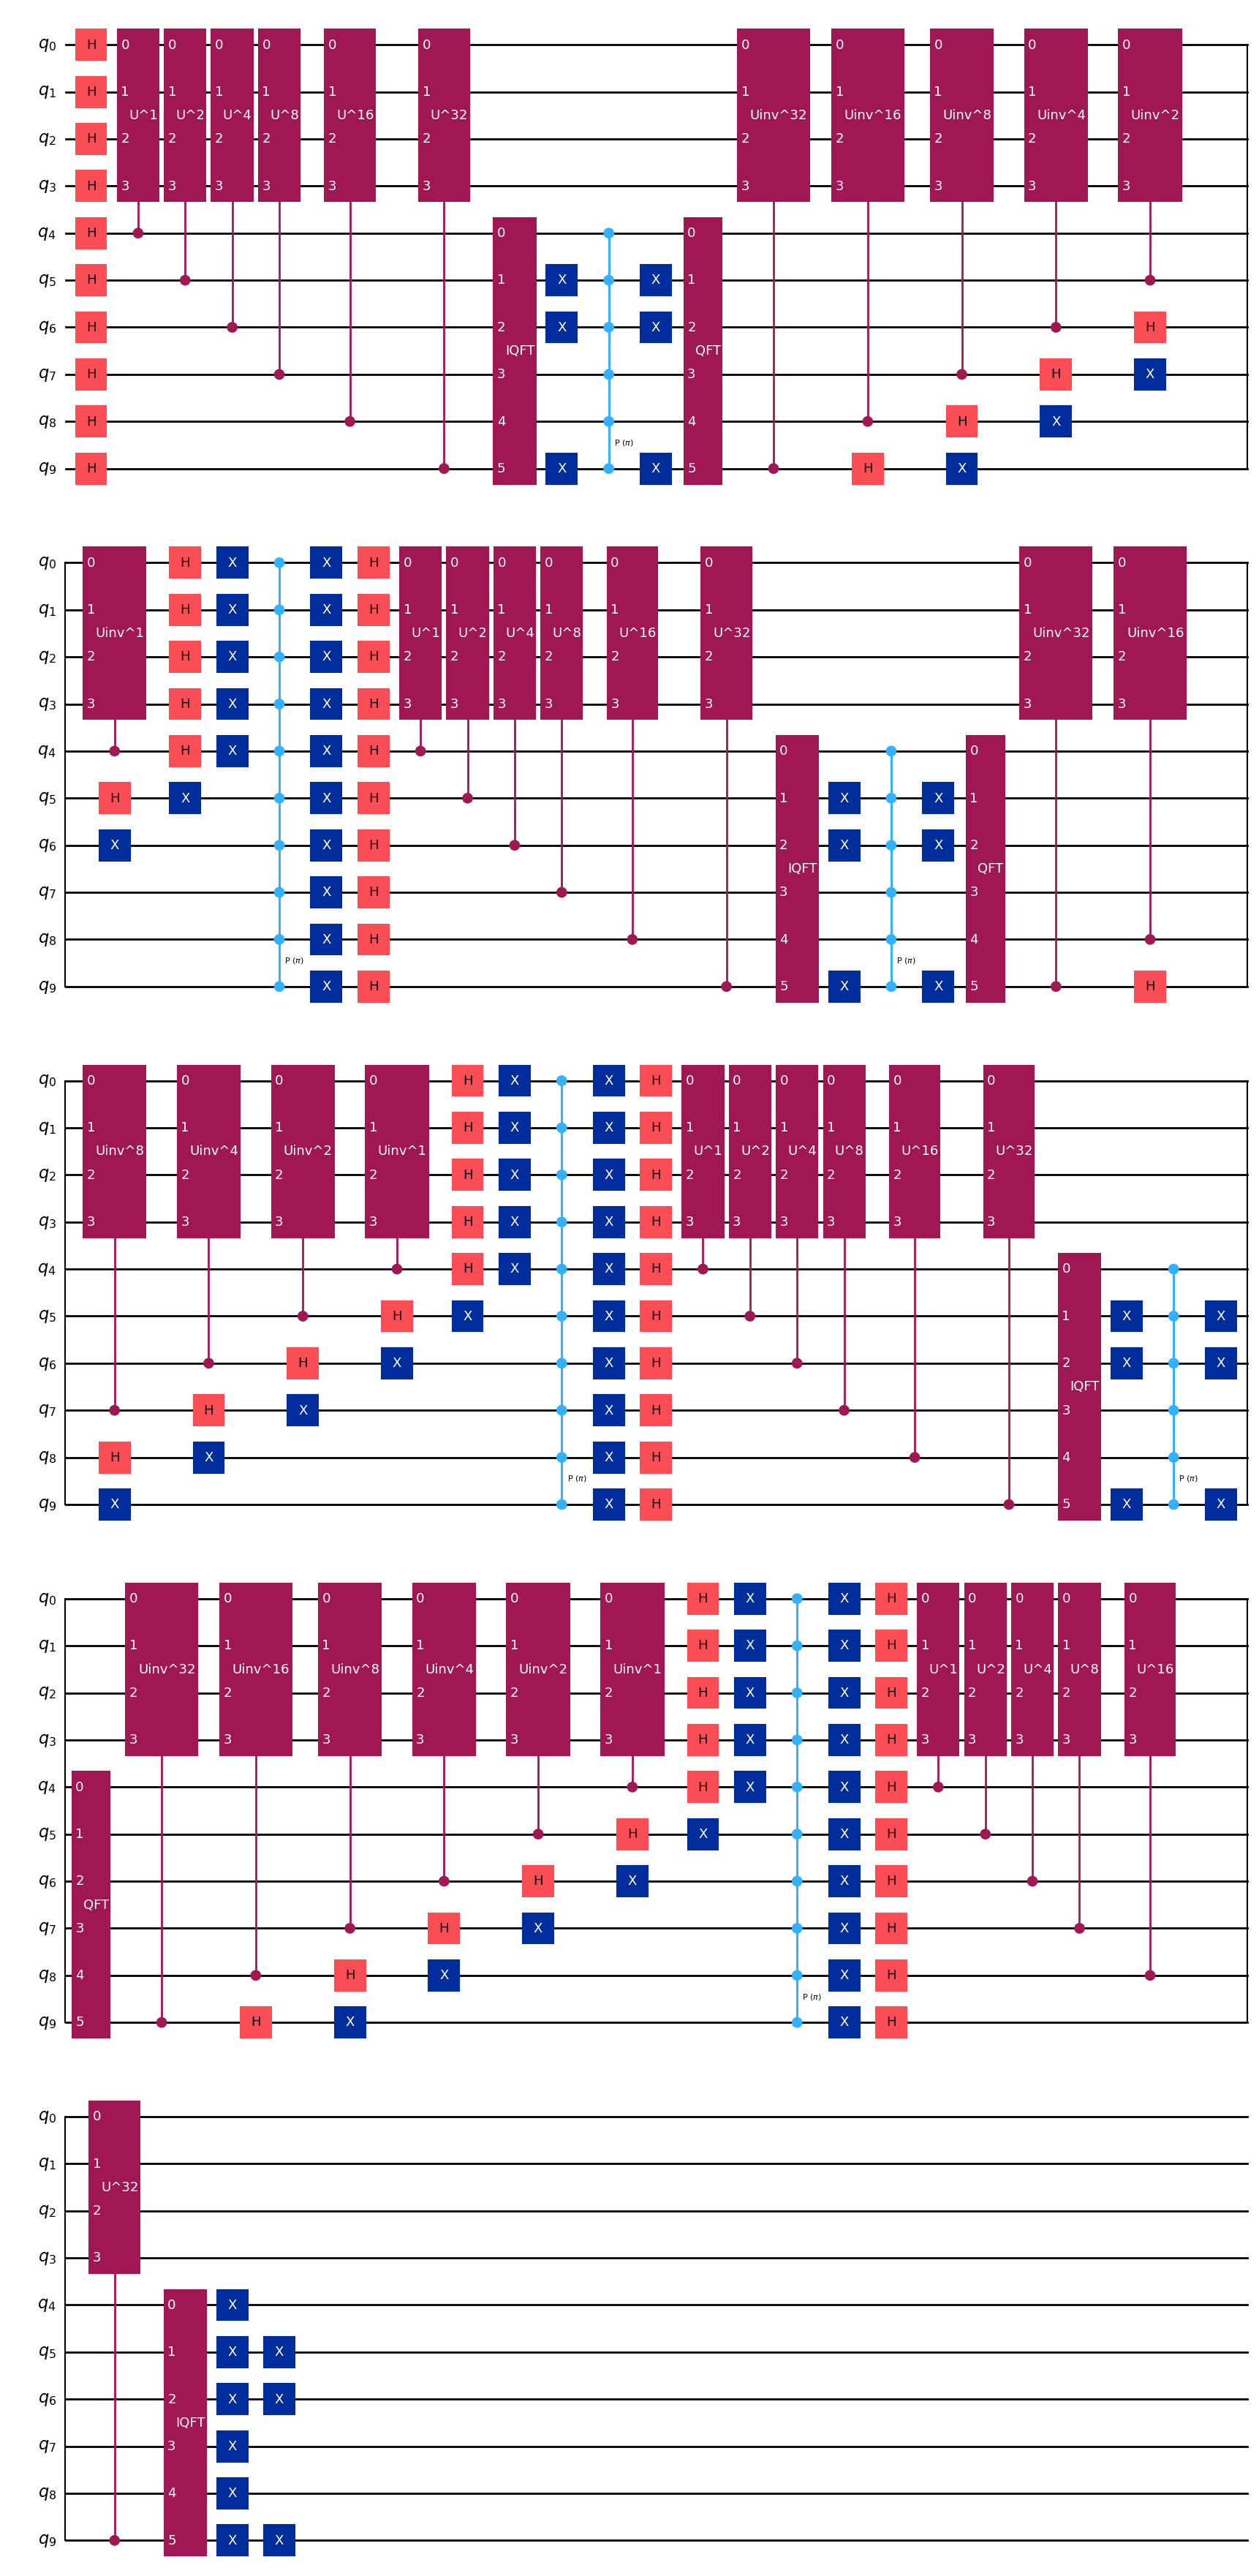

In [25]:
# The rightmost n bits (in our example, 4 bits) represent the x value. There is a 96% probability that we will get the correct
# answer |1011>, i.e., x = 11. 

# We finish by reverting all ancillary bits to 0s. Since the ancillary bits in the correct answer are currently all 1s (due to 
# the fact that we originally used X gates to convert the "correct" d-bit state to all 1s in order to set up an MCZ-based
# oracle), we simply apply an X gate to each of the d bits (in our case, the leftmost 6 bits).

qc.x(range(n,n+d))

state = Statevector.from_instruction(qc)
qc.draw('mpl')

In [26]:
state.draw('latex')

<IPython.core.display.Latex object>

In [ ]:
# As desired, the ancillary bits in the dominant state are now all 0s and the non-ancillary bits represent the correct x.